# Fluxonium spectrum and cryoscope detuning simulation

## TL;DR

For the requested Fluxonium parameters $E_J=4$ GHz, $E_C=1$ GHz, and $E_L=0.7$ GHz, the simulated $f_{01}$ transition changes from about 5.133 GHz at $\Phi_\mathrm{ext}=0$ to 5.081 GHz, 4.878 GHz, and 0.355 GHz at 0.1, 0.2, and 0.5 $\Phi_0$, respectively. Thus, flux amplitude alone does not determine whether a cryoscope signal is visible: the relevant quantity is the Ramsey phase increment $2\pi\Delta f\Delta t$. A very large excursion toward 0.5 $\Phi_0$ can actually make phase unwrapping harder.


## Context & Methods

This notebook uses `scqubits` from the `scqenv` environment to calculate the Fluxonium spectrum and then simulates a Ramsey-style cryoscope measurement. It deliberately distinguishes:

- external flux $\Phi_\mathrm{ext}/\Phi_0$; and
- accumulated Ramsey phase $\varphi_R$ in radians.

### Key assumptions

- Energies are expressed in GHz, as used by `scqubits`.
- The qubit starts at the zero-flux sweet spot.
- The illustrative flux-line step response contains a 2 ns and an 18 ns exponential component.
- Gen v6 runs at 9584.64 MS/s, matching the firmware information recorded in this repository.
- The simulated measurement records both Ramsey quadratures and adds independent Gaussian noise.
- The line model and noise level are illustrative; replace them with measured cryoscope data for calibration.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.signal import savgol_filter
import scqubits as scq

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(20260725)

EJ_GHZ = 4.0
EC_GHZ = 1.0
EL_GHZ = 0.7
CUTOFF = 160
GEN_V6_FS_MSPS = 9584.64
GEN_V6_DT_NS = 1000.0 / GEN_V6_FS_MSPS

print(f'Gen v6 envelope sample interval: {GEN_V6_DT_NS:.6f} ns')
print(f'scqubits version: {scq.__version__}')

Gen v6 envelope sample interval: 0.104334 ns
scqubits version: 4.3.1


## Fluxonium spectrum

The first calculation sweeps external flux from 0 to 0.5 $\Phi_0$ and extracts the lowest transition frequencies.


In [2]:
fluxonium = scq.Fluxonium(
    EJ=EJ_GHZ,
    EC=EC_GHZ,
    EL=EL_GHZ,
    flux=0.0,
    cutoff=CUTOFF,
    truncated_dim=12,
)

flux_grid = np.linspace(0.0, 0.5, 301)
eigenvalues = np.empty((len(flux_grid), 4))

for index, flux_value in enumerate(flux_grid):
    fluxonium.flux = flux_value
    eigenvalues[index] = fluxonium.eigenvals(evals_count=4)

f01_ghz = eigenvalues[:, 1] - eigenvalues[:, 0]
f12_ghz = eigenvalues[:, 2] - eigenvalues[:, 1]
f02_half_ghz = (eigenvalues[:, 2] - eigenvalues[:, 0]) / 2
f01_spline = CubicSpline(flux_grid, f01_ghz)
f01_idle_ghz = float(f01_spline(0.0))


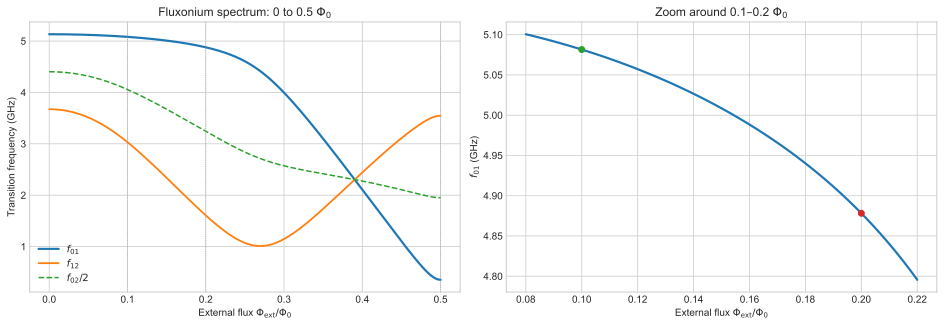

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), constrained_layout=True)

axes[0].plot(flux_grid, f01_ghz, label=r'$f_{01}$', linewidth=2.2)
axes[0].plot(flux_grid, f12_ghz, label=r'$f_{12}$', linewidth=1.8)
axes[0].plot(flux_grid, f02_half_ghz, label=r'$f_{02}/2$', linewidth=1.5, linestyle='--')
for marker_flux in (0.1, 0.2, 0.5):
    axes[0].axvline(marker_flux, color='0.65', linewidth=0.8, linestyle=':')
axes[0].set(
    xlabel=r'External flux $\Phi_\mathrm{ext}/\Phi_0$',
    ylabel='Transition frequency (GHz)',
    title='Fluxonium spectrum: 0 to 0.5 $\Phi_0$',
)
axes[0].legend()

zoom_mask = (flux_grid >= 0.08) & (flux_grid <= 0.22)
axes[1].plot(flux_grid[zoom_mask], f01_ghz[zoom_mask], color='C0', linewidth=2.2)
axes[1].scatter([0.1, 0.2], f01_spline([0.1, 0.2]), color=['C2', 'C3'], zorder=3)
axes[1].set(
    xlabel=r'External flux $\Phi_\mathrm{ext}/\Phi_0$',
    ylabel=r'$f_{01}$ (GHz)',
    title='Zoom around 0.1–0.2 $\Phi_0$',
)
plt.show()

In [4]:
probe_fluxes = np.array([0.0, 0.1, 0.2, 0.5])
probe_f01_ghz = f01_spline(probe_fluxes)
print(f'{"flux/Phi0":>10} {"f01 (GHz)":>12} {"detuning (MHz)":>16}')
for flux_value, frequency_ghz in zip(probe_fluxes, probe_f01_ghz):
    detuning_mhz = 1000 * (frequency_ghz - f01_idle_ghz)
    print(f'{flux_value:10.3f} {frequency_ghz:12.6f} {detuning_mhz:16.3f}')

 flux/Phi0    f01 (GHz)   detuning (MHz)
     0.000     5.132659            0.000
     0.100     5.081491          -51.169
     0.200     4.878197         -254.463
     0.500     0.354755        -4777.904


## Cryoscope model

The next cells apply an assumed flux-line step response and convert the instantaneous external flux into qubit detuning through the nonlinear simulated spectrum. Ramsey phase is obtained from

$$\varphi_R(t)=2\pi\int_0^t \Delta f(\tau)\,d\tau.$$


In [5]:
time_ns = np.arange(0.0, 60.0 + GEN_V6_DT_NS / 2, GEN_V6_DT_NS)

def normalized_flux_step(time_values_ns):
    # Starts at zero and approaches one. Coefficients sum to one.
    response = (
        1.0
        - 0.70 * np.exp(-time_values_ns / 2.0)
        - 0.30 * np.exp(-time_values_ns / 18.0)
    )
    # Small illustrative damped ringing; sin(0)=0 preserves the zero initial value.
    response += 0.025 * np.exp(-time_values_ns / 12.0) * np.sin(2 * np.pi * time_values_ns / 5.5)
    return response

def physical_cryoscope_trace(target_flux):
    flux_trace = target_flux * normalized_flux_step(time_ns)
    frequency_trace_ghz = f01_spline(np.clip(flux_trace, 0.0, 0.5))
    detuning_trace_ghz = frequency_trace_ghz - f01_idle_ghz
    phase_trace_rad = 2 * np.pi * np.cumsum(detuning_trace_ghz) * GEN_V6_DT_NS
    return flux_trace, detuning_trace_ghz, phase_trace_rad

target_fluxes = (0.1, 0.2, 0.5)
physical_traces = {target: physical_cryoscope_trace(target) for target in target_fluxes}

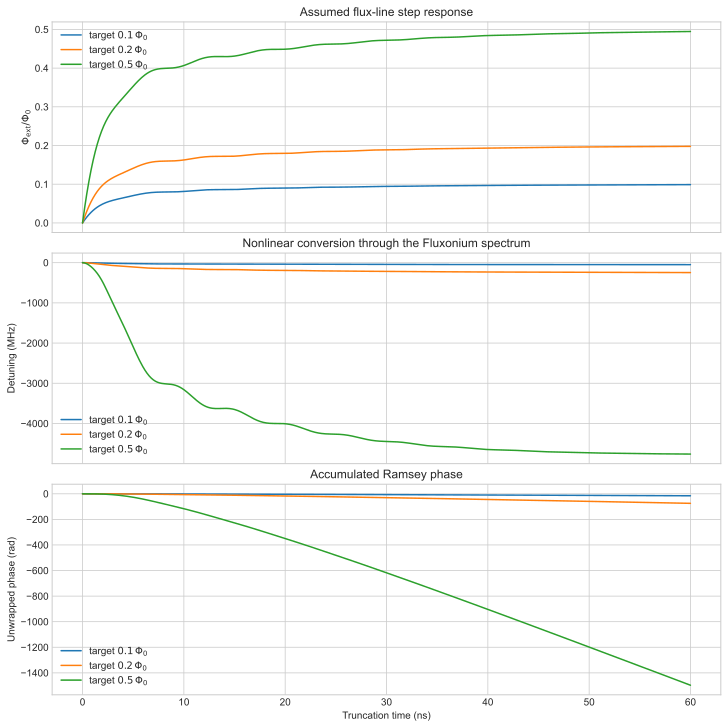

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True, constrained_layout=True)

for target_flux, (flux_trace, detuning_trace_ghz, phase_trace_rad) in physical_traces.items():
    label = rf'target ${target_flux:.1f}\,\Phi_0$'
    axes[0].plot(time_ns, flux_trace, label=label)
    axes[1].plot(time_ns, 1000 * detuning_trace_ghz, label=label)
    axes[2].plot(time_ns, phase_trace_rad, label=label)

axes[0].set_ylabel(r'$\Phi_\mathrm{ext}/\Phi_0$')
axes[0].set_title('Assumed flux-line step response')
axes[1].set_ylabel('Detuning (MHz)')
axes[1].set_title('Nonlinear conversion through the Fluxonium spectrum')
axes[2].set_ylabel('Unwrapped phase (rad)')
axes[2].set_xlabel('Truncation time (ns)')
axes[2].set_title('Accumulated Ramsey phase')
for axis in axes:
    axis.legend(loc='best')
plt.show()

## Noisy two-quadrature reconstruction

The physical waveform remains on the Gen v6 sample grid, but the simulated experiment uses one cryoscope point every eight waveform samples. This gives a truncation step of about 0.835 ns. Both $I\propto\cos\varphi_R$ and $Q\propto\sin\varphi_R$ are measured before phase unwrapping and differentiation.


In [7]:
CRYOSCOPE_STRIDE = 8
CONTRAST = 0.85
IQ_NOISE_STD = 0.035
sample_indices = np.arange(0, len(time_ns), CRYOSCOPE_STRIDE)
sample_times_ns = time_ns[sample_indices]
effective_dt_ns = CRYOSCOPE_STRIDE * GEN_V6_DT_NS

def measure_and_reconstruct(phase_trace_rad):
    true_phase = phase_trace_rad[sample_indices]
    measured_i = CONTRAST * np.cos(true_phase) + rng.normal(0, IQ_NOISE_STD, len(true_phase))
    measured_q = CONTRAST * np.sin(true_phase) + rng.normal(0, IQ_NOISE_STD, len(true_phase))
    measured_phase = np.unwrap(np.arctan2(measured_q, measured_i))
    smooth_phase = savgol_filter(measured_phase, 15, 3, mode='interp')
    reconstructed_detuning_ghz = np.gradient(smooth_phase, sample_times_ns) / (2 * np.pi)
    return measured_i, measured_q, measured_phase, reconstructed_detuning_ghz

print(f'Cryoscope truncation step: {effective_dt_ns:.6f} ns')

Cryoscope truncation step: 0.834669 ns


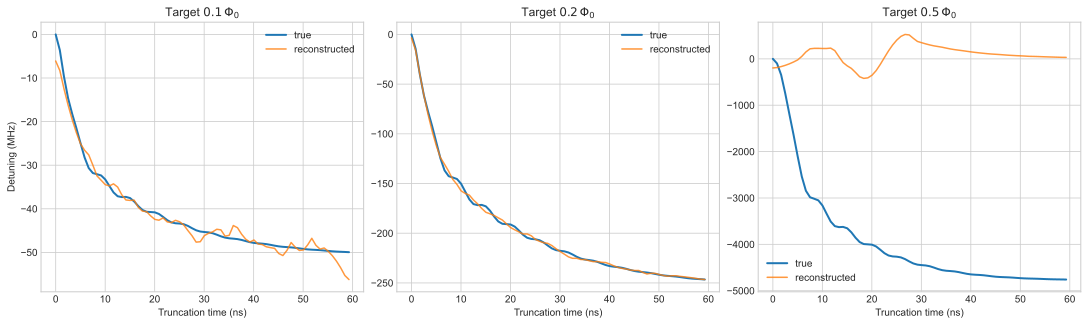

 flux/Phi0   detune MHz   |dphi| rad     RMSE MHz
     0.100      -51.169        0.268        1.879
     0.200     -254.463        1.334        2.550
     0.500    -4777.904       25.057     4210.764


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharex=True, constrained_layout=True)
reconstruction_rows = []

for axis, target_flux in zip(axes, target_fluxes):
    flux_trace, true_detuning_ghz, true_phase_rad = physical_traces[target_flux]
    _, _, measured_phase, reconstructed_detuning_ghz = measure_and_reconstruct(true_phase_rad)
    sampled_true_detuning_ghz = true_detuning_ghz[sample_indices]
    steady_phase_step = 2 * np.pi * abs(float(f01_spline(target_flux) - f01_idle_ghz)) * effective_dt_ns
    rmse_mhz = 1000 * np.sqrt(np.mean((reconstructed_detuning_ghz - sampled_true_detuning_ghz) ** 2))
    reconstruction_rows.append({
        'target_flux_Phi0': target_flux,
        'steady_detuning_MHz': 1000 * float(f01_spline(target_flux) - f01_idle_ghz),
        'steady_abs_phase_step_rad': steady_phase_step,
        'detuning_RMSE_MHz': rmse_mhz,
    })
    axis.plot(sample_times_ns, 1000 * sampled_true_detuning_ghz, label='true', linewidth=2)
    axis.plot(sample_times_ns, 1000 * reconstructed_detuning_ghz, label='reconstructed', alpha=0.8)
    axis.set_title(rf'Target ${target_flux:.1f}\,\Phi_0$')
    axis.set_xlabel('Truncation time (ns)')
    axis.legend()

axes[0].set_ylabel('Detuning (MHz)')
plt.show()

print(f'{"flux/Phi0":>10} {"detune MHz":>12} {"|dphi| rad":>12} {"RMSE MHz":>12}')
for row in reconstruction_rows:
    print(f'{row["target_flux_Phi0"]:10.3f} {row["steady_detuning_MHz"]:12.3f} '
          f'{row["steady_abs_phase_step_rad"]:12.3f} {row["detuning_RMSE_MHz"]:12.3f}')

## Weak versus adequate Ramsey phase visibility

The following is a measurement-SNR illustration independent of the Fluxonium conversion above. It compares a response whose full observable phase feature is only 0.15 rad with one whose feature is 0.50 rad, using the same readout contrast and noise. This is useful because $\Phi/\Phi_0$ and Ramsey phase in radians must not be treated as the same quantity.


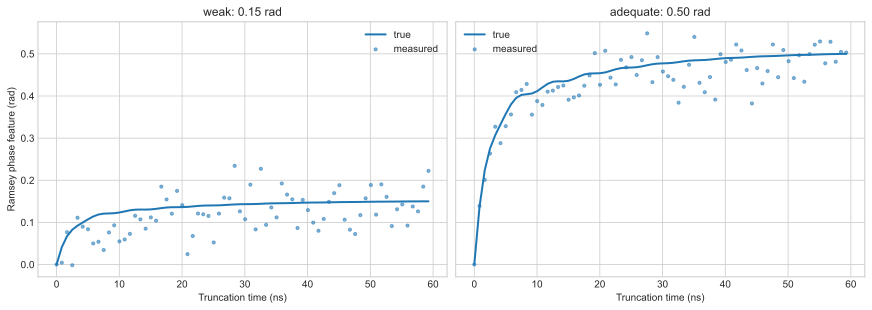

                case   span rad   RMSE rad    span/RMSE
      weak: 0.15 rad      0.150      0.046        3.270
  adequate: 0.50 rad      0.500      0.039       12.901


In [9]:
phase_feature_shape = normalized_flux_step(sample_times_ns)
phase_feature_shape /= phase_feature_shape[-1]
phase_cases_rad = {'weak: 0.15 rad': 0.15, 'adequate: 0.50 rad': 0.50}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True, constrained_layout=True)
phase_visibility_rows = []

for axis, (case_name, phase_scale) in zip(axes, phase_cases_rad.items()):
    true_phase = phase_scale * phase_feature_shape
    measured_i = CONTRAST * np.cos(true_phase) + rng.normal(0, IQ_NOISE_STD, len(true_phase))
    measured_q = CONTRAST * np.sin(true_phase) + rng.normal(0, IQ_NOISE_STD, len(true_phase))
    estimated_phase = np.unwrap(np.arctan2(measured_q, measured_i))
    estimated_phase -= estimated_phase[0]
    true_phase -= true_phase[0]
    phase_rmse = np.sqrt(np.mean((estimated_phase - true_phase) ** 2))
    phase_visibility_rows.append({
        'case': case_name,
        'phase_span_rad': np.ptp(true_phase),
        'phase_RMSE_rad': phase_rmse,
        'span_to_RMSE': np.ptp(true_phase) / phase_rmse,
    })
    axis.plot(sample_times_ns, true_phase, label='true', linewidth=2)
    axis.scatter(sample_times_ns, estimated_phase, label='measured', s=10, alpha=0.55)
    axis.set_title(case_name)
    axis.set_xlabel('Truncation time (ns)')
    axis.legend()

axes[0].set_ylabel('Ramsey phase feature (rad)')
plt.show()

print(f'{"case":>20} {"span rad":>10} {"RMSE rad":>10} {"span/RMSE":>12}')
for row in phase_visibility_rows:
    print(f'{row["case"]:>20} {row["phase_span_rad"]:10.3f} '
          f'{row["phase_RMSE_rad"]:10.3f} {row["span_to_RMSE"]:12.3f}')

## Raw X/Y data and reusable processing

The functions below retain shot-level Ramsey quadratures with array layout `[flux index, truncation-time index, shot index]`. `process_cryoscope_xy` performs averaging, optional offset/rotation correction, phase unwrapping, Savitzky–Golay smoothing, and conversion from phase slope to detuning. The same interface can be used with hardware X/Y arrays.


In [10]:
RAW_SHOTS = 256

def simulate_raw_xy_dataset(
    flux_values,
    *,
    shots=RAW_SHOTS,
    stride=CRYOSCOPE_STRIDE,
    contrast=CONTRAST,
    noise_std=IQ_NOISE_STD,
    seed=0,
):
    flux_values = np.asarray(flux_values, dtype=float)
    indices = np.arange(0, len(time_ns), stride)
    times = time_ns[indices]
    local_rng = np.random.default_rng(seed)

    shape = (len(flux_values), len(times), shots)
    x_raw = np.empty(shape)
    y_raw = np.empty(shape)
    true_flux = np.empty(shape[:2])
    true_detuning_ghz = np.empty(shape[:2])
    true_phase_rad = np.empty(shape[:2])

    for flux_index, target_flux in enumerate(flux_values):
        flux_trace, detuning_trace, phase_trace = physical_cryoscope_trace(target_flux)
        sampled_phase = phase_trace[indices]
        true_flux[flux_index] = flux_trace[indices]
        true_detuning_ghz[flux_index] = detuning_trace[indices]
        true_phase_rad[flux_index] = sampled_phase
        x_center = contrast * np.cos(sampled_phase)
        y_center = contrast * np.sin(sampled_phase)
        x_raw[flux_index] = x_center[:, None] + local_rng.normal(0, noise_std, (len(times), shots))
        y_raw[flux_index] = y_center[:, None] + local_rng.normal(0, noise_std, (len(times), shots))

    return {
        'target_flux_Phi0': flux_values,
        'time_ns': times,
        'x_raw': x_raw,
        'y_raw': y_raw,
        'true_flux_Phi0': true_flux,
        'true_detuning_GHz': true_detuning_ghz,
        'true_phase_rad': true_phase_rad,
        'shots': shots,
        'stride': stride,
    }


def process_cryoscope_xy(
    dataset,
    *,
    x_offset=0.0,
    y_offset=0.0,
    iq_rotation_rad=0.0,
    smooth_window=15,
    polyorder=3,
):
    x_mean = np.mean(dataset['x_raw'], axis=-1) - x_offset
    y_mean = np.mean(dataset['y_raw'], axis=-1) - y_offset
    complex_mean = (x_mean + 1j * y_mean) * np.exp(-1j * iq_rotation_rad)
    wrapped_phase = np.angle(complex_mean)
    unwrapped_phase = np.unwrap(wrapped_phase, axis=1)

    n_times = unwrapped_phase.shape[1]
    valid_window = min(smooth_window, n_times if n_times % 2 else n_times - 1)
    valid_window = max(valid_window, polyorder + 2 + (polyorder % 2))
    if valid_window % 2 == 0:
        valid_window -= 1
    smooth_phase = savgol_filter(
        unwrapped_phase, valid_window, polyorder, axis=1, mode='interp'
    )
    detuning_ghz = np.gradient(smooth_phase, dataset['time_ns'], axis=1) / (2 * np.pi)

    shots = dataset['x_raw'].shape[-1]
    return {
        'x_mean': x_mean,
        'y_mean': y_mean,
        'x_sem': np.std(dataset['x_raw'], axis=-1, ddof=1) / np.sqrt(shots),
        'y_sem': np.std(dataset['y_raw'], axis=-1, ddof=1) / np.sqrt(shots),
        'wrapped_phase_rad': wrapped_phase,
        'unwrapped_phase_rad': unwrapped_phase,
        'smooth_phase_rad': smooth_phase,
        'detuning_GHz': detuning_ghz,
    }


def save_raw_xy_npz(path, dataset):
    # Optional export for later processing; not called automatically.
    np.savez_compressed(path, **dataset)

## Compare narrow and wide flux ranges

Two datasets are generated with identical shots, timing, contrast, and noise: a narrow 0.10–0.20 $\Phi_0$ range and a wide 0–0.50 $\Phi_0$ range. The raw arrays remain available as `raw_narrow` and `raw_wide`.


In [11]:
narrow_flux_values = np.linspace(0.10, 0.20, 6)
wide_flux_values = np.linspace(0.00, 0.50, 11)

raw_narrow = simulate_raw_xy_dataset(narrow_flux_values, seed=101)
raw_wide = simulate_raw_xy_dataset(wide_flux_values, seed=202)
processed_narrow = process_cryoscope_xy(raw_narrow)
processed_wide = process_cryoscope_xy(raw_wide)

print('raw_narrow X/Y shape:', raw_narrow['x_raw'].shape, raw_narrow['y_raw'].shape)
print('raw_wide   X/Y shape:', raw_wide['x_raw'].shape, raw_wide['y_raw'].shape)
print('axis order: [flux, truncation time, shot]')

raw_narrow X/Y shape: (6, 72, 256) (6, 72, 256)
raw_wide   X/Y shape: (11, 72, 256) (11, 72, 256)
axis order: [flux, truncation time, shot]


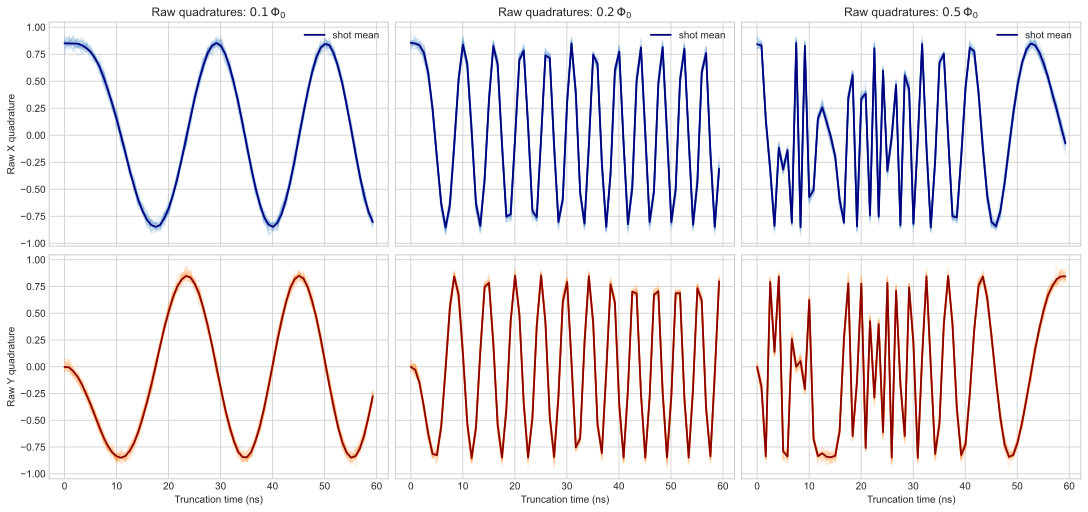

In [12]:
preview_fluxes = (0.1, 0.2, 0.5)
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True, sharey='row', constrained_layout=True)

for column, target_flux in enumerate(preview_fluxes):
    flux_index = int(np.argmin(np.abs(raw_wide['target_flux_Phi0'] - target_flux)))
    times = raw_wide['time_ns']
    for shot in range(24):
        axes[0, column].plot(times, raw_wide['x_raw'][flux_index, :, shot], color='C0', alpha=0.10)
        axes[1, column].plot(times, raw_wide['y_raw'][flux_index, :, shot], color='C1', alpha=0.10)
    axes[0, column].plot(times, processed_wide['x_mean'][flux_index], color='navy', linewidth=1.8, label='shot mean')
    axes[1, column].plot(times, processed_wide['y_mean'][flux_index], color='darkred', linewidth=1.8, label='shot mean')
    axes[0, column].set_title(rf'Raw quadratures: ${target_flux:.1f}\,\Phi_0$')
    axes[1, column].set_xlabel('Truncation time (ns)')
    axes[0, column].legend(loc='upper right')

axes[0, 0].set_ylabel('Raw X quadrature')
axes[1, 0].set_ylabel('Raw Y quadrature')
plt.show()

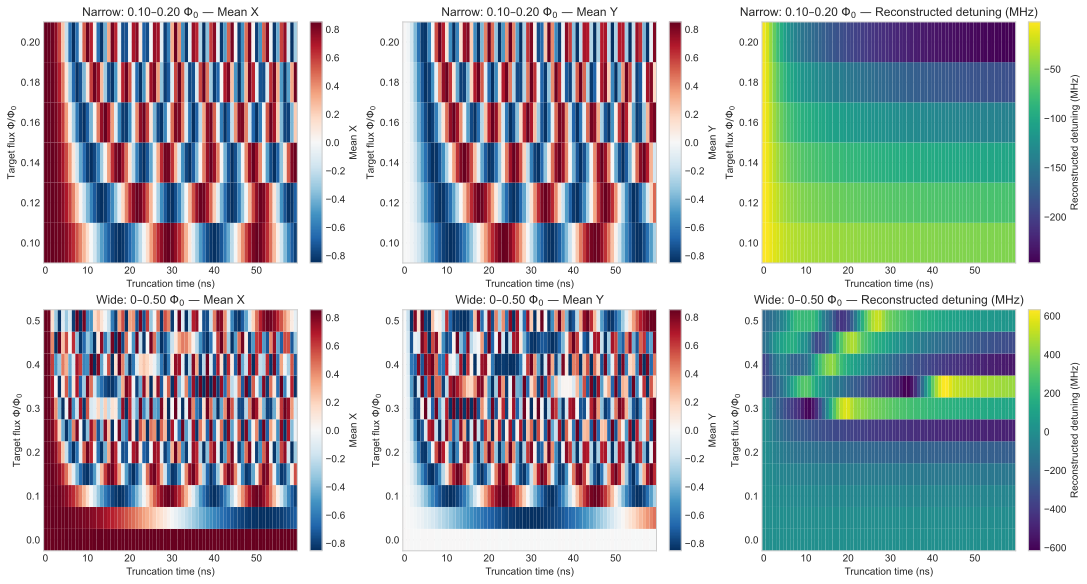

In [13]:
range_cases = [
    ('Narrow: 0.10–0.20 $\Phi_0$', raw_narrow, processed_narrow),
    ('Wide: 0–0.50 $\Phi_0$', raw_wide, processed_wide),
]
fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)

for row_index, (title, raw_data, processed_data) in enumerate(range_cases):
    times = raw_data['time_ns']
    fluxes = raw_data['target_flux_Phi0']
    panels = [
        (processed_data['x_mean'], 'Mean X', 'RdBu_r', None),
        (processed_data['y_mean'], 'Mean Y', 'RdBu_r', None),
        (1000 * processed_data['detuning_GHz'], 'Reconstructed detuning (MHz)', 'viridis', None),
    ]
    for column_index, (values, label, cmap, limits) in enumerate(panels):
        image = axes[row_index, column_index].pcolormesh(
            times, fluxes, values, shading='auto', cmap=cmap
        )
        fig.colorbar(image, ax=axes[row_index, column_index], label=label)
        axes[row_index, column_index].set_title(f'{title} — {label}')
        axes[row_index, column_index].set_xlabel('Truncation time (ns)')
        axes[row_index, column_index].set_ylabel(r'Target flux $\Phi/\Phi_0$')
plt.show()

In [14]:
def summarize_range(name, raw_data, processed_data):
    error_ghz = processed_data['detuning_GHz'] - raw_data['true_detuning_GHz']
    rmse_by_flux_mhz = 1000 * np.sqrt(np.mean(error_ghz**2, axis=1))
    max_true_phase_step = np.max(np.abs(np.diff(raw_data['true_phase_rad'], axis=1)), axis=1)
    return {
        'name': name,
        'median_RMSE_MHz': float(np.median(rmse_by_flux_mhz)),
        'worst_RMSE_MHz': float(np.max(rmse_by_flux_mhz)),
        'max_phase_step_rad': float(np.max(max_true_phase_step)),
        'aliased_flux_points': int(np.sum(max_true_phase_step >= np.pi)),
        'flux_points': len(raw_data['target_flux_Phi0']),
    }

range_summaries = [
    summarize_range('0.10–0.20 Phi0', raw_narrow, processed_narrow),
    summarize_range('0–0.50 Phi0', raw_wide, processed_wide),
]
print(f'{"range":>18} {"median RMSE":>13} {"worst RMSE":>12} {"max |dphi|":>12} {"aliased":>10}')
for row in range_summaries:
    alias_text = f'{row["aliased_flux_points"]}/{row["flux_points"]}'
    print(f'{row["name"]:>18} {row["median_RMSE_MHz"]:13.3f} '
          f'{row["worst_RMSE_MHz"]:12.3f} {row["max_phase_step_rad"]:12.3f} '
          f'{alias_text:>10}')

             range   median RMSE   worst RMSE   max |dphi|    aliased
    0.10–0.20 Phi0         1.102        2.195        1.292        0/6
       0–0.50 Phi0         4.574     4210.840       24.952       5/11


## Takeaways

- With these Fluxonium parameters, 0.1 $\Phi_0$ already produces about 51 MHz detuning from the zero-flux idle point, while 0.2 $\Phi_0$ produces about 254 MHz. Whether that is visible depends on truncation step, readout contrast, averaging, and phase noise.
- At an eight-sample Gen v6 truncation step, 0.1 $\Phi_0$ gives a moderate steady-state phase increment. The 0.5 $\Phi_0$ case accumulates many radians between adjacent measurement points and can alias during phase unwrapping. More flux is therefore not automatically better.
- The notebook now preserves shot-level raw X/Y arrays and keeps simulation separate from `process_cryoscope_xy`, so measured hardware quadratures can use the same processing path.
- A 0.15 rad total phase feature is only a few times the assumed phase noise and is visibly noisy. A 0.50 rad feature is substantially easier to recover under the same conditions.
- Comparing 0.10–0.20 $\Phi_0$ with 0–0.50 $\Phi_0$ shows why a wide flux range is useful for spectroscopy but can be unsuitable for one fixed cryoscope time step: large-detuning points exceed the phase-unwrapping limit.
- For hardware, choose flux amplitude and cryoscope time stride together so adjacent phase increments are comfortably above phase noise but below $\pi$; approximately 0.1–0.5 rad per point is a useful starting region.
- Fit or smooth unwrapped phase before differentiation. Direct point-to-point differentiation at the 0.104 ns Gen v6 sample interval strongly amplifies noise.
- After measuring the real step response, replace `normalized_flux_step` with the measured response and use the same sample grid to design and validate an inverse FIR/IIR predistortion waveform.
